Linear Regression -> Train R2: 0.9069042307708008 Test R2: 0.9086544371263179
Polynomial (deg=2) -> Train R2: 0.9586396155851544 Test R2: 0.962326334679857
Polynomial (deg=10) -> Train R2: 0.9616497139168566 Test R2: 0.9628792290117483


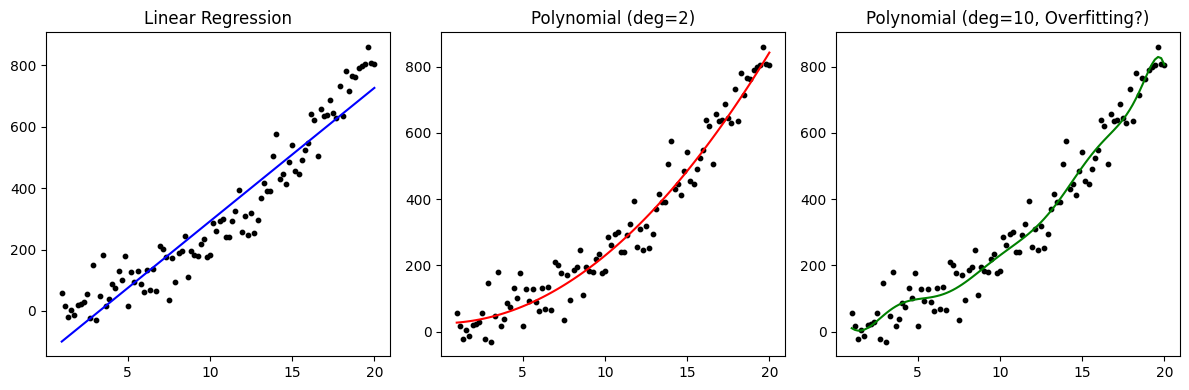

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Larger dataset (non-linear relation with some noise)
X = np.linspace(1, 20, 100).reshape(-1, 1)   # 100 points between 1 and 20
y = 2 * X.squeeze()**2 + 3*X.squeeze() + 5   # true quadratic relation
y = y + np.random.normal(0, 50, size=len(y)) # add noise

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Simple Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin_train = lin_model.predict(X_train)
y_pred_lin_test = lin_model.predict(X_test)

# Polynomial Regression (degree=2, good fit)
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

poly_model2 = LinearRegression()
poly_model2.fit(X_train_poly2, y_train)
y_pred_poly2_train = poly_model2.predict(X_train_poly2)
y_pred_poly2_test = poly_model2.predict(X_test_poly2)

# Polynomial Regression (degree=10, possible overfitting)
poly10 = PolynomialFeatures(degree=10)
X_train_poly10 = poly10.fit_transform(X_train)
X_test_poly10 = poly10.transform(X_test)

poly_model10 = LinearRegression()
poly_model10.fit(X_train_poly10, y_train)
y_pred_poly10_train = poly_model10.predict(X_train_poly10)
y_pred_poly10_test = poly_model10.predict(X_test_poly10)

# R2 Scores
print("Linear Regression -> Train R2:", r2_score(y_train, y_pred_lin_train), 
      "Test R2:", r2_score(y_test, y_pred_lin_test))
print("Polynomial (deg=2) -> Train R2:", r2_score(y_train, y_pred_poly2_train), 
      "Test R2:", r2_score(y_test, y_pred_poly2_test))
print("Polynomial (deg=10) -> Train R2:", r2_score(y_train, y_pred_poly10_train), 
      "Test R2:", r2_score(y_test, y_pred_poly10_test))

# Visualization
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(X, y, color="black", s=10)
plt.plot(X, lin_model.predict(X), color="blue")
plt.title("Linear Regression")

plt.subplot(1,3,2)
plt.scatter(X, y, color="black", s=10)
plt.plot(X, poly_model2.predict(poly2.transform(X)), color="red")
plt.title("Polynomial (deg=2)")

plt.subplot(1,3,3)
plt.scatter(X, y, color="black", s=10)
plt.plot(X, poly_model10.predict(poly10.transform(X)), color="green")
plt.title("Polynomial (deg=10, Overfitting?)")

plt.tight_layout()
plt.show()


In [ ]:
#Linear Regression: Too simple → misses curvature (underfits).

#Polynomial (deg=2): Best balance of bias & variance → matches underlying data.

#Polynomial (deg=10): Not much worse here, but risky → prone to overfitting if dataset is noisy or smaller.